## NB6 — Keep / Split / Merge Recommendation

Combines NB1 (GSEA identity), NB2 (redundancy / GEP tree), NB4 (ROGUE purity), NB5 (GPN regulatory states) into one action per label — **keep, split, or merge** — plus the K-range it applies to. Output: `recommendations.tsv`.

**Scope:** every label NB2 assigned to a GEP, excluding `Ambiguous/Mixed`. Covers both original cell-type labels (e.g. `Mono_CD14_ID1`) and NB2's coarser family labels (e.g. `Monocyte_family`).

**Decision logic** — merge is tested first, then split; the first rule that fires wins:

- **Merge** — two witnesses naming the same partner. Redundancy (NB2 cross-K NES correlation, gated at `REDUNDANCY_R_MIN`) is mandatory, plus at least one of: ambiguous co-occurrence (NB1) or chief rival (NB5). `MERGE_MIN_VOTES` of 3 signals must agree.
- **Split** — all three required: the label's GEPs beat their baseline ROGUE purity more often than they lose (margin ≥ `SPLIT_PURER_MARGIN`), that gain beats a null control (≥ `NULL_PASS_RATE_MIN`), and NB5's win_rate doesn't show the label's cells mostly settling into a committed identity (veto above `LOW_WIN_RATE_MAX`). Missing GPN data never blocks a split.
- **Keep** — neither rule fires. Reported with the label's longest consecutive run of assigned K values.

**Confidence** grades the call, never changes it: one point each for ≥10 samples, a null-control pass, ≥50% of GEPs identity-supported, and NB5's population-level `cn_enrichment` agreeing with the action (disagreeing subtracts a point). Score ≥3 → High, ≥1 → Medium, else Low.

**Guarantee:** every non-`Ambiguous/Mixed` label appears exactly once with a valid action — coverage failures raise, never silently drop (11).


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 30)


#### 1. Configuration

In [ ]:
# Same dataset as NB1/NB2/NB4/NB5
NB1_DIR = "hnc_combined5000hvg_clanp_results/k3-35_gsea_celltype_results"
NB2_DIR = "hnc_combined5000hvg_clanp_results/k3-35_corr-tree_kl-divergence"
NB4_DIR = "hnc_combined5000hvg_clanp_results/rogue_purity_results_per_gep"
NB5_DIR = "hnc_combined5000hvg_clanp_results/gpn_results_per_gep"

# Must match NB4's MEMBERSHIP_TAG (section 7 there) — NB4 tags its GEP-membership-dependent
# outputs so results from different membership rules never silently mix. Update this if NB4's
# MIN_USAGE_RATIO changes. baseline_specific/baseline_family are untagged: they never depended
# on GEP membership.
NB4_MEMBERSHIP_TAG = "softratio0.7"

AMBIGUOUS_LABEL = "Ambiguous/Mixed"
FAMILY_SUFFIX = "_family"

# Split gate (8): required purer/less_pure margin and null-control pass rate
SPLIT_PURER_MARGIN = 0.15
NULL_PASS_RATE_MIN = 0.6

# GPN population-level bands (9, confidence-only): cn_enrichment above GPN_AGREE_HIGH
# or below GPN_AGREE_LOW counts as a clear signal
GPN_AGREE_HIGH = 1.2
GPN_AGREE_LOW  = 0.8

# Merge: votes needed among {redundancy clears REDUNDANCY_R_MIN, ambiguous
# co-occurrence agrees, GPN chief-rival agrees}
MERGE_MIN_VOTES = 2

# Split: GPN win_rate veto threshold — a label whose dominant GEP(s) mostly
# settle (win_rate above this) isn't showing internal tension
LOW_WIN_RATE_MAX = 0.5

STATE_ORDER = ["Low activity", "Dominance", "Competition", "Consensus", "Negotiation"]

OUT_DIR = "hnc_combined5000hvg_clanp_results/recommendations"
os.makedirs(OUT_DIR, exist_ok=True)
print("Configuration loaded.")

#### 2. Load upstream tables (NB1, NB2, NB4, NB5 — nothing recomputed here)

In [ ]:
program_class = pd.read_csv(f"{NB1_DIR}/gep_program_class.tsv", sep='\t')
per_gep_labels = pd.read_csv(f"{NB2_DIR}/per_gep_labels.tsv", sep='\t')
gep_persistence = pd.read_csv(f"{NB2_DIR}/gep_persistence.csv")
lineage_persistence = pd.read_csv(f"{NB2_DIR}/lineage_persistence.csv").set_index('lineage_id')
redundancy = pd.read_csv(f"{NB2_DIR}/celltype_redundancy_matrix.csv", index_col=0)
family_between = pd.read_csv(f"{NB2_DIR}/family_coherence_between.csv")

split_merge = pd.read_csv(f"{NB4_DIR}/rogue_split_merge_signal_{NB4_MEMBERSHIP_TAG}.csv")
null_control = pd.read_csv(f"{NB4_DIR}/rogue_null_control_{NB4_MEMBERSHIP_TAG}.csv")
contamination = pd.read_csv(f"{NB4_DIR}/rogue_contamination_{NB4_MEMBERSHIP_TAG}.csv")
baseline_specific = pd.read_csv(f"{NB4_DIR}/rogue_baseline_specific.csv")
baseline_family = pd.read_csv(f"{NB4_DIR}/rogue_baseline_family.csv")

# gpn_states.tsv is per-cell (10^5-10^6 rows) — only load the columns 9 needs
gpn_states = pd.read_csv(f"{NB5_DIR}/gpn_states.tsv", sep='\t',
                          usecols=['K', 'gep', 'state', 'label'])

# NB5 12 output — per-(K, GEP) win rate and chief rival, read directly by 7/8
gep_profile = pd.read_csv(f"{NB5_DIR}/gep_negotiation_profile.csv", dtype={'gep': str, 'chief_rival': str})

# Every label ever assigned to a GEP, minus the ambiguous placeholder
labels = sorted(set(per_gep_labels['label'].unique()) - {AMBIGUOUS_LABEL})

def label_kind(label):
    return 'family' if label.endswith(FAMILY_SUFFIX) else 'specific'

print(f"{len(labels)} labels to score: {labels}")
print(per_gep_labels['label'].value_counts().to_string())

#### 3. Unified evidence table

One row per (sample, K, GEP): NB4's split/merge signal, joined with its null-control gate and its contamination diagnostic.

In [4]:
# Join the split/merge signal with its null-control gate and contamination diagnostic
evidence = split_merge.merge(
    null_control[['sample', 'K', 'gep', 'beats_null_median', 'null_zscore']],
    on=['sample', 'K', 'gep'], how='left'
).merge(
    contamination[['sample', 'K', 'gep', 'contamination_delta']],
    on=['sample', 'K', 'gep'], how='left'
)
print(f"{len(evidence)} (sample, K, GEP) evidence rows")
evidence['label_kind'].value_counts()


6211 (sample, K, GEP) evidence rows


label_kind
ambiguous    3020
specific     1820
family       1371
Name: count, dtype: int64

#### 4. Per-label ROGUE aggregation

Per label: `purer_frac` / `less_pure_frac` vs. the annotation baseline, `null_pass_rate` (does the purity gain beat NB4's null control), contamination delta (QC only, not decisive), and the label's own baseline ROGUE.

In [5]:
rows = []
for label in labels:
    sub = evidence[evidence['label'] == label]
    rec_counts = sub['recommendation'].value_counts(normalize=True)
    purer_rows = sub[sub['recommendation'] == 'purer']

    # Original labels and family labels have separate baseline tables
    kind = label_kind(label)
    if kind == 'specific':
        own_baseline = baseline_specific.loc[baseline_specific['original_label'] == label, 'ROGUE'].median()
    else:
        own_baseline = baseline_family.loc[baseline_family['family_label'] == label, 'ROGUE'].median()

    rows.append(dict(
        label=label, label_kind=kind,
        n_gep_rows=len(sub), n_samples=sub['sample'].nunique(),
        purer_frac=rec_counts.get('purer', 0.0),
        less_pure_frac=rec_counts.get('less_pure', 0.0),
        tie_frac=rec_counts.get('tie', 0.0),
        null_pass_rate=purer_rows['beats_null_median'].mean() if len(purer_rows) else np.nan,
        median_delta_ROGUE=sub['delta_ROGUE'].median(),
        median_contamination_delta=sub['contamination_delta'].median(),
        own_baseline_ROGUE=own_baseline,
    ))

agg = pd.DataFrame(rows).set_index('label')
agg.round(3)


,label_kind,n_gep_rows,n_samples,purer_frac,less_pure_frac,tie_frac,null_pass_rate,median_delta_ROGUE,median_contamination_delta,own_baseline_ROGUE
label,,,,,,,,,,
DC_family,family,664,61,0.497,0.060,0.410,0.685,0.055,0.000,0.944
DC_pDC,specific,734,63,0.004,0.135,0.658,1.000,0.000,0.000,0.960
Mac_IL1B,specific,32,17,0.000,0.344,0.281,NaN,-0.060,NaN,0.868
Mac_SPP1,specific,55,48,0.018,0.109,0.091,1.000,-0.040,0.080,0.890
Macrophage_family,family,293,20,0.846,0.000,0.154,0.633,0.116,0.000,0.757
Mast,specific,159,7,0.025,0.019,0.956,1.000,0.000,0.000,0.975
Mono_CD14_ID1,specific,221,56,0.000,0.050,0.041,NaN,-0.050,0.050,0.943
Mono_CD16,specific,412,59,0.005,0.187,0.529,1.000,-0.030,0.036,0.970
Monocyte_family,family,414,53,0.307,0.002,0.691,0.929,0.034,0.015,0.929


#### 5. Per-label identity confidence (NB1)

How often each label's GEPs had a clear GSEA identity match, an ambiguous one, or none at all.

In [6]:
# Attach NB1's GSEA identity classification to each (K, GEP) row
pgl_pc = per_gep_labels.merge(program_class[['k', 'gep', 'program_class']], on=['k', 'gep'], how='left')

id_rows = []
for label in labels:
    counts = pgl_pc.loc[pgl_pc['label'] == label, 'program_class'].value_counts(normalize=True)
    id_rows.append(dict(
        label=label,
        frac_identity_supported=counts.get('identity_supported', 0.0),
        frac_identity_ambiguous=counts.get('identity_ambiguous', 0.0),
        frac_non_identity_unresolved=counts.get('non_identity_unresolved', 0.0),
    ))
id_conf = pd.DataFrame(id_rows).set_index('label')
id_conf.round(3)


,frac_identity_supported,frac_identity_ambiguous,frac_non_identity_unresolved
label,,,
DC_family,0.235,0.353,0.412
DC_pDC,0.333,0.143,0.524
Mac_IL1B,0.500,0.500,0.000
Mac_SPP1,0.500,0.500,0.000
Macrophage_family,0.273,0.045,0.682
Mast,0.423,0.077,0.500
Mono_CD14_ID1,1.000,0.000,0.000
Mono_CD16,0.889,0.111,0.000
Monocyte_family,0.000,0.800,0.200


#### 6. Resolved K-range

Check whether NB2's lineage structure can be used for a per-label K-range: if one lineage swallows almost every (K, GEP) node, it can't.

In [7]:
# Check how node counts are distributed across lineages
print("Largest lineages by node count (n_nodes / 627 total (K,GEP) pairs):")
print(lineage_persistence.sort_values('n_nodes', ascending=False).head(5)[
    ['n_nodes', 'k_min', 'k_max', 'consecutive_span', 'dominant_celltype', 'celltype_purity']
].to_string())


Largest lineages by node count (n_nodes / 627 total (K,GEP) pairs):
            n_nodes  k_min  k_max  consecutive_span dominant_celltype  celltype_purity
lineage_id                                                                            
2               595      3     35                33   Ambiguous/Mixed            0.711
0                 7      3      9                 7   Ambiguous/Mixed            0.571
7                 4     30     33                 4   Ambiguous/Mixed            1.000
8                 4     30     32                 3   Ambiguous/Mixed            1.000
1                 3      3      5                 3   Ambiguous/Mixed            1.000


One lineage contains nearly all (K, GEP) nodes and spans almost the whole K sweep, so lineage structure can't report a per-label K-range.

Instead, apply NB2 13's `longest_consecutive_interval` helper directly to `per_gep_labels.tsv`: the longest consecutive run of K values where the pipeline actually assigned this exact label. Works for family labels too.

In [8]:
def longest_consecutive_interval(ks):
    # Find the longest run of consecutive integers in a set of K values
    ks = sorted(set(ks))
    if not ks:
        return None, None, None
    best_start = best_end = start = prev = ks[0]
    for k in ks[1:]:
        if k == prev + 1:
            prev = k
        else:
            if (prev - start) > (best_end - best_start):
                best_start, best_end = start, prev
            start = prev = k
    if (prev - start) > (best_end - best_start):
        best_start, best_end = start, prev
    return best_end - best_start + 1, best_start, best_end

k_range_rows = []
for label in labels:
    ks = per_gep_labels.loc[per_gep_labels['label'] == label, 'k']
    span, k_start, k_end = longest_consecutive_interval(ks)
    k_range_rows.append(dict(label=label, resolved_k_min=k_start, resolved_k_max=k_end,
                              resolved_consecutive_span=span, n_k_total=ks.nunique()))

k_range = pd.DataFrame(k_range_rows).set_index('label')
k_range


,resolved_k_min,resolved_k_max,resolved_consecutive_span,n_k_total
label,,,,
DC_family,6,25,20,29
DC_pDC,6,15,10,21
Mac_IL1B,25,25,1,2
Mac_SPP1,19,19,1,4
Macrophage_family,6,15,10,26
Mast,5,23,19,25
Mono_CD14_ID1,7,9,3,4
Mono_CD16,12,15,4,9
Monocyte_family,20,23,4,10


#### 7. Merge-candidate detection

**7a.** Set `REDUNDANCY_R_MIN` from the redundancy correlation distribution (95th percentile) rather than an arbitrary threshold.

In [9]:
# Off-diagonal = correlation between two different labels (diagonal is a label with itself)
off_diag = redundancy.to_numpy()[~np.eye(len(redundancy), dtype=bool)]
print("Redundancy (cross-K median NES-profile Pearson R) off-diagonal quantiles:")
print(pd.Series(off_diag).quantile([.5, .75, .9, .95, .99]).round(3).to_string())

# Use the 95th percentile as the "clearly redundant" cutoff
REDUNDANCY_R_MIN = float(np.quantile(off_diag, 0.95))
print(f"\nREDUNDANCY_R_MIN (95th percentile) = {REDUNDANCY_R_MIN:.3f}")


Redundancy (cross-K median NES-profile Pearson R) off-diagonal quantiles:
0.50    0.123
0.75    0.553
0.90    0.749
0.95    0.787
0.99    0.929

REDUNDANCY_R_MIN (95th percentile) = 0.787


**7b.** Helpers: each label's top redundancy partner (GSEA correlation matrix, specific labels only), top ambiguous co-occurrence partner (NB1, both directions of a tied-identity GEP pair), and top GPN chief-rival partner (NB5 12, weighted by dominant-cell count per (K, GEP) row).

In [10]:
def top_redundancy_partner(label):
    # Highest-correlated other label in the redundancy matrix
    if label not in redundancy.index:
        return None, np.nan
    row = redundancy.loc[label].drop(label, errors='ignore')
    if row.empty:
        return None, np.nan
    return row.idxmax(), row.max()

# Build a symmetric label/partner table from the ambiguous GEPs' tied top-2 identities
ambig = program_class[program_class['program_class'] == 'identity_ambiguous']
_ambig_pairs = pd.concat([
    ambig[['top_identity_label', 'second_identity_label']].rename(
        columns={'top_identity_label': 'label', 'second_identity_label': 'partner'}),
    ambig[['top_identity_label', 'second_identity_label']].rename(
        columns={'second_identity_label': 'label', 'top_identity_label': 'partner'}),
], ignore_index=True)

def top_ambiguous_partner(label):
    # Most frequent co-occurring label in tied-identity GEPs
    sub = _ambig_pairs[_ambig_pairs['label'] == label]
    if sub.empty:
        return None, 0, 0
    counts = sub['partner'].value_counts()
    return counts.idxmax(), int(counts.max()), len(sub)

def top_gpn_rival_partner(label):
    # Chief-rival label most common across this label's (K, GEP) rows, weighted by
    # n_dominant_cells so a row backed by 500 cells counts more than one backed by 5
    sub = gep_profile[(gep_profile['label'] == label) & gep_profile['chief_rival_label'].notna()]
    if sub.empty:
        return None, 0.0
    weights = sub.groupby('chief_rival_label')['n_dominant_cells'].sum()
    partner = weights.idxmax()
    rate = weights.max() / weights.sum()
    return partner, rate

print("Helpers defined.")


Helpers defined.


**7c.** `merge_candidate = True` when redundancy clears `REDUNDANCY_R_MIN` and at least one other signal names the same partner — `MERGE_MIN_VOTES` of 3. For specific labels the other signals are ambiguous co-occurrence and GPN chief-rival. Family labels use `family_coherence_between.csv` in place of the redundancy matrix, plus the same GPN chief-rival check as their required second vote.

In [11]:
merge_rows = []
for label in labels:
    kind = label_kind(label)
    gpn_partner, gpn_rate = top_gpn_rival_partner(label)

    if kind == 'specific':
        redund_partner, redund_r = top_redundancy_partner(label)
        ambig_partner, ambig_n, ambig_total = top_ambiguous_partner(label)

        # Each signal casts one vote for redund_partner: redundancy (must clear
        # threshold), ambiguous co-occurrence, GPN chief rival. Needs MERGE_MIN_VOTES;
        # redundancy alone is never enough.
        redund_clears = redund_partner is not None and redund_r >= REDUNDANCY_R_MIN
        ambig_votes = redund_partner is not None and ambig_partner == redund_partner
        gpn_votes = redund_partner is not None and gpn_partner == redund_partner
        votes = int(redund_clears) + int(ambig_votes) + int(gpn_votes)
        agree = redund_clears and votes >= MERGE_MIN_VOTES

        kind_str = '+'.join(
            v for v, flag in [('redundancy', redund_clears), ('ambiguous', ambig_votes), ('gpn_rival', gpn_votes)]
            if flag
        )
        merge_rows.append(dict(
            label=label, merge_candidate=agree,
            merge_partner=redund_partner if agree else None,
            redundancy_partner=redund_partner, redundancy_R=redund_r,
            ambiguous_partner=ambig_partner,
            ambiguous_partner_rate=(ambig_n / ambig_total if ambig_total else np.nan),
            gpn_rival_partner=gpn_partner, gpn_rival_rate=gpn_rate,
            merge_votes=votes,
            merge_evidence_kind=(kind_str + '_agree') if agree else None,
        ))
    else:
        # Family labels: between_R plus GPN chief rival — same two-signal bar as
        # specific labels.
        fam_name = label[:-len(FAMILY_SUFFIX)]
        sub = family_between[family_between['family_pair'].str.contains(fam_name)]
        if sub.empty:
            merge_rows.append(dict(label=label, merge_candidate=False, merge_partner=None,
                                    redundancy_partner=None, redundancy_R=np.nan,
                                    ambiguous_partner=None, ambiguous_partner_rate=np.nan,
                                    gpn_rival_partner=gpn_partner, gpn_rival_rate=gpn_rate,
                                    merge_votes=0, merge_evidence_kind=None))
            continue
        best = sub.loc[sub['median_between_R'].idxmax()]
        other_fam = [f for f in best['family_pair'].split(' ↔ ') if f != fam_name][0]
        redund_partner = f"{other_fam}{FAMILY_SUFFIX}"
        redund_clears = best['median_between_R'] >= REDUNDANCY_R_MIN
        gpn_votes = gpn_partner == redund_partner
        votes = int(redund_clears) + int(gpn_votes)
        agree = redund_clears and votes >= MERGE_MIN_VOTES

        merge_rows.append(dict(
            label=label, merge_candidate=agree,
            merge_partner=redund_partner if agree else None,
            redundancy_partner=redund_partner, redundancy_R=best['median_between_R'],
            ambiguous_partner=None, ambiguous_partner_rate=np.nan,
            gpn_rival_partner=gpn_partner, gpn_rival_rate=gpn_rate,
            merge_votes=votes,
            merge_evidence_kind=(
                'family_between_R+gpn_rival_agree' if agree
                else 'family_between_R_only (no GPN corroboration)' if redund_clears
                else None
            ),
        ))

merge_df = pd.DataFrame(merge_rows).set_index('label')
merge_df


,merge_candidate,merge_partner,redundancy_partner,redundancy_R,ambiguous_partner,ambiguous_partner_rate,gpn_rival_partner,gpn_rival_rate,merge_votes,merge_evidence_kind
label,,,,,,,,,,
DC_family,False,None,Macrophage_family,0.375000,None,NaN,Ambiguous/Mixed,0.322426,0,None
DC_pDC,False,None,Mast,0.776268,cDC2_CD1C,0.642857,Ambiguous/Mixed,0.762135,0,None
Mac_IL1B,False,None,Mono_TIL,0.766334,Mono_TIL,0.333333,Ambiguous/Mixed,1.000000,1,None
Mac_SPP1,False,None,Mac_CXCL9,0.784543,Mac_CXCL9,0.450980,Ambiguous/Mixed,1.000000,1,None
Macrophage_family,False,None,DC_family,0.375000,None,NaN,Monocyte_family,0.459347,0,None
Mast,False,None,DC_pDC,0.776268,Mac_SPP1,0.600000,Ambiguous/Mixed,0.664689,0,None
Mono_CD14_ID1,True,Mono_CD14_THBS1,Mono_CD14_THBS1,0.929934,Mono_CD14_THBS1,0.500000,Macrophage_family,0.784447,2,redundancy+ambiguous_agree
Mono_CD16,False,None,Mono_Int,0.751187,Mono_Int,0.333333,Ambiguous/Mixed,0.429967,1,None
Monocyte_family,False,None,DC_family,-0.005000,None,NaN,Mono_CD16,0.898016,0,None


#### 8. Split-support flag

`split_supported` requires: `purer_frac` beats `less_pure_frac` by ≥ `SPLIT_PURER_MARGIN`, that gain beats null control (≥ `NULL_PASS_RATE_MIN`), and NB5's `win_rate` doesn't veto it.

In [ ]:
# How big is the gap between "purer" and "less pure" for each label?
agg['split_margin'] = agg['purer_frac'] - agg['less_pure_frac']
print("split_margin (purer_frac - less_pure_frac) across labels:")
print(agg['split_margin'].describe().round(3).to_string())

# win_rate (NB5 12): fraction of a GEP's dominant cells that settle into
# Consensus/Dominance rather than staying contested, weighted by n_dominant_cells
# across a label's (K, GEP) rows
def label_win_rate(label):
    sub = gep_profile[(gep_profile['label'] == label) & gep_profile['win_rate'].notna()]
    if sub.empty or sub['n_dominant_cells'].sum() == 0:
        return np.nan
    return np.average(sub['win_rate'], weights=sub['n_dominant_cells'])

agg['label_win_rate'] = [label_win_rate(l) for l in agg.index]

# win_rate > LOW_WIN_RATE_MAX means the label's cells mostly settle rather than stay contested — GPN vetoes the split
# Missing GPN data never blocks a split.
agg['gpn_contradicts_split'] = agg['label_win_rate'] > LOW_WIN_RATE_MAX
agg['split_supported'] = (
    (agg['split_margin'] >= SPLIT_PURER_MARGIN) &
    (agg['null_pass_rate'] >= NULL_PASS_RATE_MIN) &
    ~agg['gpn_contradicts_split'].fillna(False)
)
agg[['purer_frac', 'less_pure_frac', 'split_margin', 'null_pass_rate',
     'label_win_rate', 'gpn_contradicts_split', 'split_supported']].round(3)


split_margin (purer_frac - less_pure_frac) across labels:
count    10.000
mean      0.027
std       0.402
min      -0.531
25%      -0.169
50%      -0.070
75%       0.230
max       0.846


,purer_frac,less_pure_frac,split_margin,null_pass_rate,label_win_rate,gpn_contradicts_split,split_supported
label,,,,,,,
DC_family,0.497,0.060,0.437,0.685,0.543,True,False
DC_pDC,0.004,0.135,-0.131,1.000,0.537,True,False
Mac_IL1B,0.000,0.344,-0.344,NaN,0.420,False,False
Mac_SPP1,0.018,0.109,-0.091,1.000,0.411,False,False
Macrophage_family,0.846,0.000,0.846,0.633,0.556,True,False
Mast,0.025,0.019,0.006,1.000,0.906,True,False
Mono_CD14_ID1,0.000,0.050,-0.050,NaN,0.914,True,False
Mono_CD16,0.005,0.187,-0.182,1.000,0.748,True,False
Monocyte_family,0.307,0.002,0.304,0.929,0.676,True,False


#### 9. GPN population-level corroboration (confidence only)

Per label: fraction of cells in `Competition`/`Negotiation` state vs. the population fraction at the same K (computed per-K, not pooled, since state composition shifts with K). `cn_enrichment > 1` means more internal conflict than typical; `< 1` means less. Coarser than 7/8's GEP-level signals, so it stays confidence-only, checked in 10 against whatever action was already picked.

In [13]:
# Population-level Competition+Negotiation fraction, per K (the baseline to compare each label against)
pop_by_k = (gpn_states.groupby('K')['state'].value_counts(normalize=True)
            .unstack().reindex(columns=STATE_ORDER, fill_value=0.0))
pop_by_k['cn_frac'] = pop_by_k['Competition'] + pop_by_k['Negotiation']

gpn_rows = []
for label in labels:
    sub = gpn_states[gpn_states['label'] == label]
    if sub.empty:
        gpn_rows.append(dict(label=label, cn_enrichment=np.nan))
        continue
    # Same computation, but restricted to this label's cells
    by_k = (sub.groupby('K')['state'].value_counts(normalize=True)
            .unstack().reindex(columns=STATE_ORDER, fill_value=0.0))
    by_k['cn_frac'] = by_k['Competition'] + by_k['Negotiation']
    # Compare label vs. population at matching K, then take the median ratio across K
    joined = by_k[['cn_frac']].join(pop_by_k[['cn_frac']], lsuffix='_label', rsuffix='_pop').dropna()
    enrichment = (joined['cn_frac_label'] / joined['cn_frac_pop'].replace(0, np.nan)).median()
    gpn_rows.append(dict(label=label, cn_enrichment=enrichment))

gpn_df = pd.DataFrame(gpn_rows).set_index('label')
gpn_df.round(3)


,cn_enrichment
label,
DC_family,1.296
DC_pDC,0.502
Mac_IL1B,1.097
Mac_SPP1,1.001
Macrophage_family,1.882
Mast,0.242
Mono_CD14_ID1,0.390
Mono_CD16,0.880
Monocyte_family,0.813


#### 10. Decision rule + confidence

Merge tested first, then split; first rule that fires wins:

```
if merge_candidate:      action = 'merge'
elif split_supported:    action = 'split'
else:                    action = 'keep'
```

`cn_enrichment` doesn't affect the action, only confidence: it agrees when elevated for a `split` or low for a `keep`, disagrees otherwise.

In [14]:
# Bring all the per-label tables together into one final table
final = (agg.join(id_conf).join(k_range)
             .join(merge_df[['merge_candidate', 'merge_partner', 'merge_evidence_kind',
                              'redundancy_partner', 'redundancy_R', 'gpn_rival_partner',
                              'gpn_rival_rate', 'merge_votes']])
             .join(gpn_df))

def decide(row):
    # merge beats split beats keep
    if row['merge_candidate']:
        return 'merge'
    if row['split_supported']:
        return 'split'
    return 'keep'

final['action'] = final.apply(decide, axis=1)

def gpn_agreement(row):
    # Does cn_enrichment (9) agree with the action already picked?
    enr = row['cn_enrichment']
    if pd.isna(enr):
        return 'no_data'
    if row['action'] == 'split':
        return 'agrees' if enr >= GPN_AGREE_HIGH else ('disagrees' if enr <= GPN_AGREE_LOW else 'neutral')
    return 'agrees' if enr <= GPN_AGREE_LOW else ('disagrees' if enr >= GPN_AGREE_HIGH else 'neutral')

final['gpn_agreement'] = final.apply(gpn_agreement, axis=1)

def confidence(row):
    # One point each for: enough samples, null-control pass, strong GSEA identity,
    # GPN agreement (disagreement subtracts a point instead)
    score = 0
    score += 1 if row['n_samples'] >= 10 else 0
    score += 1 if (pd.notna(row['null_pass_rate']) and row['null_pass_rate'] >= NULL_PASS_RATE_MIN) else 0
    score += 1 if row['frac_identity_supported'] >= 0.5 else 0
    score += 1 if row['gpn_agreement'] == 'agrees' else (-1 if row['gpn_agreement'] == 'disagrees' else 0)
    if score >= 3:
        return 'High'
    if score >= 1:
        return 'Medium'
    return 'Low'

final['confidence'] = final.apply(confidence, axis=1)

def evidence_summary(row):
    # Human-readable justification for the action, written to the output table
    if row['action'] == 'merge':
        return (f"merges with {row['merge_partner']} ({row['merge_evidence_kind']}, "
                f"R={row['redundancy_R']:.2f}, {row['merge_votes']}/3 votes, "
                f"GPN rival={row['gpn_rival_partner']})")
    win_rate_str = f"{row['label_win_rate']:.2f}" if pd.notna(row['label_win_rate']) else "n/a"
    if row['action'] == 'split':
        return (f"purer_frac={row['purer_frac']:.2f} vs less_pure_frac={row['less_pure_frac']:.2f} "
                f"(margin={row['split_margin']:.2f}), null_pass_rate={row['null_pass_rate']:.2f}, "
                f"GPN win_rate={win_rate_str} (no veto), population {row['gpn_agreement']}")
    veto = row.get('gpn_contradicts_split', False)
    veto_str = ("GPN vetoed a would-be split"
                if (veto and row['split_margin'] >= SPLIT_PURER_MARGIN and row['null_pass_rate'] >= NULL_PASS_RATE_MIN)
                else f"GPN win_rate={win_rate_str}")
    return (f"no merge/split signal cleared threshold "
            f"(split_margin={row['split_margin']:.2f}, top redundancy partner={row['redundancy_partner']}), "
            f"{veto_str}, population {row['gpn_agreement']}")

final['evidence_summary'] = final.apply(evidence_summary, axis=1)

final[['label_kind', 'action', 'confidence', 'merge_partner', 'resolved_k_min', 'resolved_k_max',
       'resolved_consecutive_span', 'own_baseline_ROGUE', 'purer_frac', 'null_pass_rate',
       'frac_identity_supported', 'label_win_rate', 'gpn_contradicts_split', 'merge_votes',
       'cn_enrichment', 'gpn_agreement', 'n_samples', 'n_gep_rows']].round(3)


,label_kind,action,confidence,merge_partner,resolved_k_min,resolved_k_max,resolved_consecutive_span,own_baseline_ROGUE,purer_frac,null_pass_rate,frac_identity_supported,label_win_rate,gpn_contradicts_split,merge_votes,cn_enrichment,gpn_agreement,n_samples,n_gep_rows
label,,,,,,,,,,,,,,,,,,
DC_family,family,keep,Medium,None,6,25,20,0.944,0.497,0.685,0.235,0.543,True,0,1.296,disagrees,61,664
DC_pDC,specific,keep,High,None,6,15,10,0.960,0.004,1.000,0.333,0.537,True,0,0.502,agrees,63,734
Mac_IL1B,specific,keep,Medium,None,25,25,1,0.868,0.000,NaN,0.500,0.420,False,1,1.097,neutral,17,32
Mac_SPP1,specific,keep,High,None,19,19,1,0.890,0.018,1.000,0.500,0.411,False,1,1.001,neutral,48,55
Macrophage_family,family,keep,Medium,None,6,15,10,0.757,0.846,0.633,0.273,0.556,True,0,1.882,disagrees,20,293
Mast,specific,keep,Medium,None,5,23,19,0.975,0.025,1.000,0.423,0.906,True,0,0.242,agrees,7,159
Mono_CD14_ID1,specific,merge,High,Mono_CD14_THBS1,7,9,3,0.943,0.000,NaN,1.000,0.914,True,2,0.390,agrees,56,221
Mono_CD16,specific,keep,High,None,12,15,4,0.970,0.005,1.000,0.889,0.748,True,1,0.880,neutral,59,412
Monocyte_family,family,keep,Medium,None,20,23,4,0.929,0.307,0.929,0.000,0.676,True,0,0.813,neutral,53,414


#### 11. Silent-failure check

Every non-`Ambiguous/Mixed` label must appear exactly once with a valid action.

In [15]:
expected = set(labels)
got = set(final.index)

problems = []
if expected != got:
    problems.append(f"coverage mismatch: missing={expected - got}, extra={got - expected}")
if final.index.duplicated().any():
    problems.append("duplicate label rows")
if not final['action'].isin(['keep', 'split', 'merge']).all():
    problems.append(f"invalid action value(s): {set(final['action']) - {'keep','split','merge'}}")

if problems:
    raise ValueError("Silent-failure check FAILED:\n  - " + "\n  - ".join(problems))
print(f"✓ Silent-failure check passed: {len(final)} labels, full coverage, all actions valid.")


✓ Silent-failure check passed: 10 labels, full coverage, all actions valid.


#### 12. Write `recommendations.tsv`

In [16]:
OUT_COLS = [
    'label_kind', 'action', 'confidence', 'merge_partner', 'resolved_k_min', 'resolved_k_max',
    'resolved_consecutive_span', 'own_baseline_ROGUE', 'purer_frac', 'less_pure_frac',
    'null_pass_rate', 'median_contamination_delta', 'frac_identity_supported',
    'frac_identity_ambiguous', 'frac_non_identity_unresolved',
    'label_win_rate', 'gpn_contradicts_split', 'gpn_rival_partner', 'merge_votes',
    'cn_enrichment', 'gpn_agreement', 'n_samples', 'n_gep_rows', 'evidence_summary',
]

recommendations = final[OUT_COLS].reset_index().rename(columns={'index': 'label'})
out_path = os.path.join(OUT_DIR, 'recommendations.tsv')
recommendations.to_csv(out_path, sep='\t', index=False)
print(f"Wrote {out_path}  ({len(recommendations)} rows)\n")
print(recommendations['action'].value_counts().to_string())


Wrote hnc_combined5000hvg_clanp_results/recommendations/recommendations.tsv  (10 rows)

action
keep     9
merge    1


#### 13. Visualization — summary

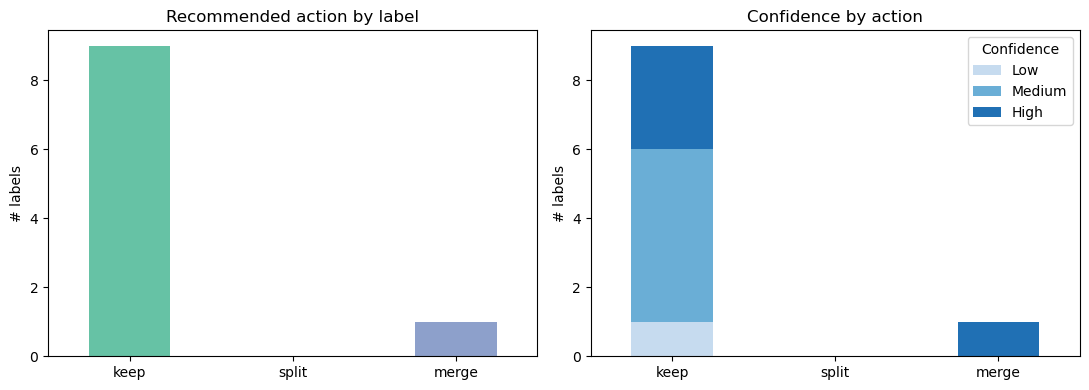

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

action_order = ['keep', 'split', 'merge']
conf_order = ['Low', 'Medium', 'High']
palette = dict(zip(action_order, sns.color_palette('Set2', n_colors=3)))

# Left: how many labels got each action
ax = axes[0]
final['action'].value_counts().reindex(action_order, fill_value=0).plot(
    kind='bar', ax=ax, color=[palette[a] for a in action_order])
ax.set(title='Recommended action by label', xlabel='', ylabel='# labels')
ax.tick_params(axis='x', rotation=0)

# Right: confidence breakdown within each action
ax = axes[1]
ct = pd.crosstab(final['action'], final['confidence']).reindex(index=action_order, columns=conf_order, fill_value=0)
ct.plot(kind='bar', stacked=True, ax=ax, color=sns.color_palette('Blues', n_colors=3))
ax.set(title='Confidence by action', xlabel='', ylabel='# labels')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Confidence')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'recommendation_summary.png'), dpi=150, bbox_inches='tight')
plt.show()


In [18]:
display_cols = ['label_kind', 'action', 'confidence', 'merge_partner',
                 'resolved_k_min', 'resolved_k_max', 'own_baseline_ROGUE',
                 'purer_frac', 'null_pass_rate', 'label_win_rate', 'gpn_rival_partner',
                 'gpn_agreement', 'n_samples']
(final[display_cols]
 .sort_values(['action', 'confidence'], ascending=[True, False])
 .round(3)
 .style.background_gradient(subset=['own_baseline_ROGUE', 'purer_frac'], cmap='RdYlGn')
)


,label_kind,action,confidence,merge_partner,resolved_k_min,resolved_k_max,own_baseline_ROGUE,purer_frac,null_pass_rate,label_win_rate,gpn_rival_partner,gpn_agreement,n_samples
label,,,,,,,,,,,,,
DC_family,family,keep,Medium,None,6,25,0.944000,0.497000,0.685000,0.543000,Ambiguous/Mixed,disagrees,61
Mac_IL1B,specific,keep,Medium,None,25,25,0.868000,0.000000,nan,0.420000,Ambiguous/Mixed,neutral,17
Macrophage_family,family,keep,Medium,None,6,15,0.757000,0.846000,0.633000,0.556000,Monocyte_family,disagrees,20
Mast,specific,keep,Medium,None,5,23,0.975000,0.025000,1.000000,0.906000,Ambiguous/Mixed,agrees,7
Monocyte_family,family,keep,Medium,None,20,23,0.929000,0.307000,0.929000,0.676000,Mono_CD16,neutral,53
cDC2_CD33,specific,keep,Low,None,20,23,0.962000,0.000000,nan,0.477000,Mono_CD16,disagrees,54
DC_pDC,specific,keep,High,None,6,15,0.960000,0.004000,1.000000,0.537000,Ambiguous/Mixed,agrees,63
Mac_SPP1,specific,keep,High,None,19,19,0.890000,0.018000,1.000000,0.411000,Ambiguous/Mixed,neutral,48
Mono_CD16,specific,keep,High,None,12,15,0.970000,0.005000,1.000000,0.748000,Ambiguous/Mixed,neutral,59


#### 14. Summary

In [19]:
print("NB6 keep/split/merge recommendations complete.\n")
print(f"Labels scored: {len(final)}")
print(final['action'].value_counts().to_string())
print()
print("Merge candidates:")
print(final.loc[final['action'] == 'merge', ['merge_partner', 'merge_evidence_kind']].to_string()
      if (final['action'] == 'merge').any() else "  (none)")
print(f"\nOutputs written to {OUT_DIR}/:")
for f in sorted(os.listdir(OUT_DIR)):
    print(f"  {f}")


NB6 keep/split/merge recommendations complete.

Labels scored: 10
action
keep     9
merge    1

Merge candidates:
                 merge_partner         merge_evidence_kind
label                                                     
Mono_CD14_ID1  Mono_CD14_THBS1  redundancy+ambiguous_agree

Outputs written to hnc_combined5000hvg_clanp_results/recommendations/:
  recommendation_summary.png
  recommendations.tsv
